# ICD Corpus — Exploratory Analysis
**TestMATE Project | Subtask T3.2: Data Preparation**

This notebook covers the preliminary analysis of the ICD (Introduction to Data Science) slide corpus, extracted and cleaned from 9 PDF files.

**Structure:**
1. Setup & Data Loading
2. Document-Level Exploratory Analysis
3. Term Frequency (TF) Analysis
4. TF-IDF Analysis
5. Word Cloud

---
## 1. Setup & Data Loading

In [1]:
import os
import re
import sys
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# make src/ importable from within notebooks/
_nb_dir = os.path.dirname(os.path.abspath('exploratory_analysis.ipynb'))
_src_dir = os.path.abspath(os.path.join(_nb_dir, '..'))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

warnings.filterwarnings('ignore')

# plotting style
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'font.family'     : 'serif',
})
PALETTE = ['#2C5F8A', '#4C9BE8', '#A8C8E8', '#D9E8F5']

print('Libraries loaded.')

Libraries loaded.


In [2]:
from utils import STOP_WORDS, KEEP_POS, tokenize, get_nlp

print(f'Stopword list ready. Total stopwords: {len(STOP_WORDS)}')
_m = get_nlp().meta
print(f'spaCy model: {_m["name"]} | {_m["lang"]}')

Stopword list ready. Total stopwords: 785
spaCy model: core_news_sm | pt


In [3]:
from utils import load_corpus, OUTPUT_ROOT

# preview available cleaned files (latest version for each document)
_paths = sorted(glob.glob(os.path.join(OUTPUT_ROOT, '**', '*_cleaned_v*.csv'), recursive=True))
print(f'{len(_paths)} cleaned CSV file(s) available:')
for p in _paths:
    print(' ', os.path.relpath(p, OUTPUT_ROOT))

63 cleaned CSV file(s) available:
  icd_1/icd_1_v1_cleaned_v1.csv
  icd_1/icd_1_v1_cleaned_v2.csv
  icd_1/icd_1_v1_cleaned_v3.csv
  icd_1/icd_1_v1_cleaned_v4.csv
  icd_1/icd_1_v1_cleaned_v5.csv
  icd_1/icd_1_v1_cleaned_v6.csv
  icd_1/icd_1_v1_cleaned_v7.csv
  icd_2/icd_2_v1_cleaned_v1.csv
  icd_2/icd_2_v1_cleaned_v2.csv
  icd_2/icd_2_v1_cleaned_v3.csv
  icd_2/icd_2_v1_cleaned_v4.csv
  icd_2/icd_2_v1_cleaned_v5.csv
  icd_2/icd_2_v1_cleaned_v6.csv
  icd_2/icd_2_v1_cleaned_v7.csv
  icd_3/icd_3_v1_cleaned_v1.csv
  icd_3/icd_3_v1_cleaned_v2.csv
  icd_3/icd_3_v1_cleaned_v3.csv
  icd_3/icd_3_v1_cleaned_v4.csv
  icd_3/icd_3_v1_cleaned_v5.csv
  icd_3/icd_3_v1_cleaned_v6.csv
  icd_3/icd_3_v1_cleaned_v7.csv
  icd_4/icd_4_v1_cleaned_v1.csv
  icd_4/icd_4_v1_cleaned_v2.csv
  icd_4/icd_4_v1_cleaned_v3.csv
  icd_4/icd_4_v1_cleaned_v4.csv
  icd_4/icd_4_v1_cleaned_v5.csv
  icd_4/icd_4_v1_cleaned_v6.csv
  icd_4/icd_4_v1_cleaned_v7.csv
  icd_5/icd_5_v1_cleaned_v1.csv
  icd_5/icd_5_v1_cleaned_v2.csv
  icd_

In [4]:
from utils import tokenize_corpus

corpus = tokenize_corpus(load_corpus())

print(f'Corpus shape: {corpus.shape}')
print(f'Columns     : {list(corpus.columns)}')
corpus.head()

Corpus shape: (1868, 7)
Columns     : ['file', 'page', 'line', 'text', 'source_file', 'tokens', 'token_count']


,file,page,line,text,source_file,tokens,token_count
0,icd_1.pdf,1,1,Introdução à Ciência de Dados,icd_1_v1_cleaned_v7.csv,"[introdução, ciência, dado]",3
1,icd_1.pdf,1,2,Aula 01,icd_1_v1_cleaned_v7.csv,[],0
2,icd_1.pdf,1,3,Ana Rita Peixoto,icd_1_v1_cleaned_v7.csv,[],0
3,icd_1.pdf,1,4,Martim Santos,icd_1_v1_cleaned_v7.csv,[],0
4,icd_1.pdf,1,5,Miguel Teodoro,icd_1_v1_cleaned_v7.csv,[],0


---
## 2. Document-Level Analysis

In [5]:
doc_stats = (
    corpus.groupby('source_file')
    .agg(
        n_pages         = ('page',        'nunique'),
        n_lines         = ('text',        'count'),
        total_tokens    = ('token_count', 'sum'),
        avg_tokens_line = ('token_count', 'mean'),
    )
    .reset_index()
)
doc_stats['avg_tokens_page'] = (doc_stats['total_tokens'] / doc_stats['n_pages']).round(1)
doc_stats['avg_tokens_line'] = doc_stats['avg_tokens_line'].round(2)

doc_stats

,source_file,n_pages,n_lines,total_tokens,avg_tokens_line,avg_tokens_page
0,icd_1_v1_cleaned_v7.csv,30,253,555,2.19,18.5
1,icd_2_v1_cleaned_v7.csv,32,311,642,2.06,20.1
2,icd_3_v1_cleaned_v7.csv,34,383,746,1.95,21.9
3,icd_4_v1_cleaned_v7.csv,23,115,246,2.14,10.7
4,icd_5_v1_cleaned_v7.csv,8,33,66,2.00,8.2
5,icd_6_v1_cleaned_v7.csv,24,236,457,1.94,19.0
6,icd_7_v1_cleaned_v7.csv,37,287,531,1.85,14.4
7,icd_8_v1_cleaned_v7.csv,13,100,141,1.41,10.8
8,icd_9_v1_cleaned_v7.csv,26,150,279,1.86,10.7


In [6]:
summary = pd.DataFrame([{
    'total_documents'   : doc_stats.shape[0],
    'total_pages'       : doc_stats['n_pages'].sum(),
    'total_lines'       : doc_stats['n_lines'].sum(),
    'total_tokens'      : doc_stats['total_tokens'].sum(),
    'avg_pages_per_doc' : doc_stats['n_pages'].mean().round(1),
    'avg_tokens_per_doc': doc_stats['total_tokens'].mean().round(1),
    'avg_tokens_per_page': doc_stats['avg_tokens_page'].mean().round(1),
}])

summary

,total_documents,total_pages,total_lines,total_tokens,avg_pages_per_doc,avg_tokens_per_doc,avg_tokens_per_page
0,9,227,1868,3663,25.2,407.0,14.9


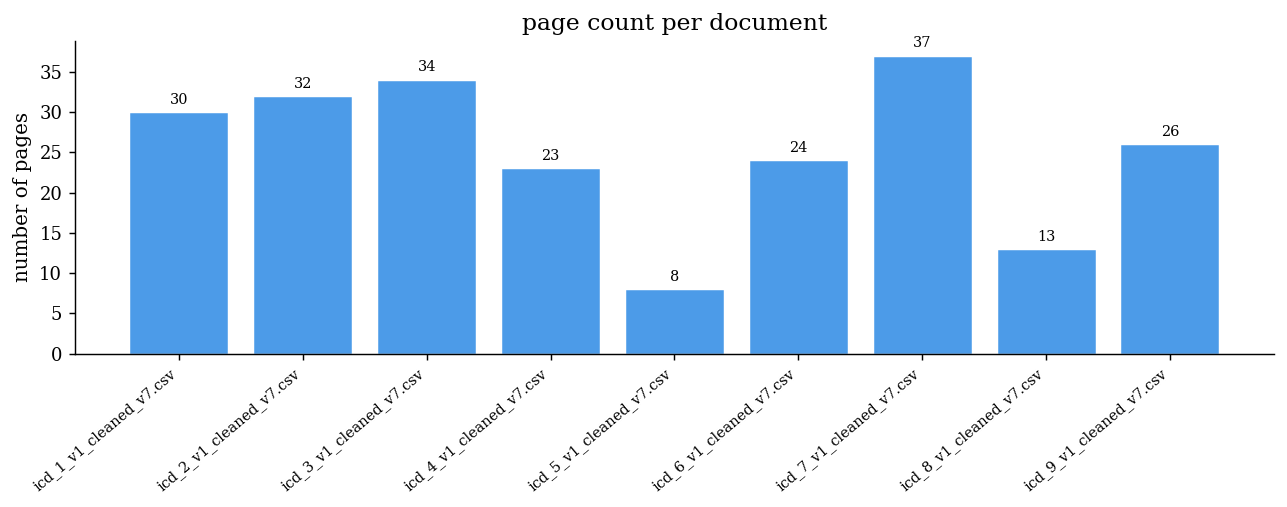

In [7]:
# pages per document
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    doc_stats['source_file'],
    doc_stats['n_pages'],
    color=PALETTE[1], edgecolor='white', linewidth=0.8
)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_ylabel('number of pages')
ax.set_title('page count per document')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

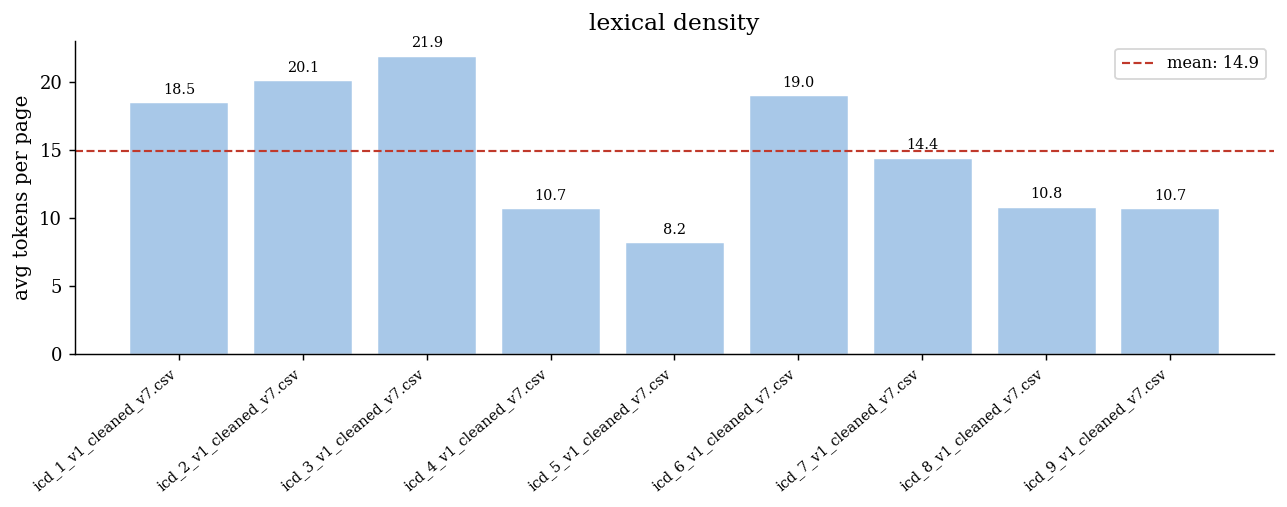

In [8]:
# avg tokens per page
# high avg_tokens_page value indicates text-dense slides;
# a low value may indicate diagram-heavy or near-empty slides.
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    doc_stats['source_file'],
    doc_stats['avg_tokens_page'],
    color=PALETTE[2], edgecolor='white', linewidth=0.8
)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax.axhline(
    doc_stats['avg_tokens_page'].mean(),
    color='#C0392B', linestyle='--', linewidth=1.2,
    label=f"mean: {doc_stats['avg_tokens_page'].mean():.1f}"
)
ax.set_ylabel('avg tokens per page')
ax.set_title('lexical density')
ax.legend(fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

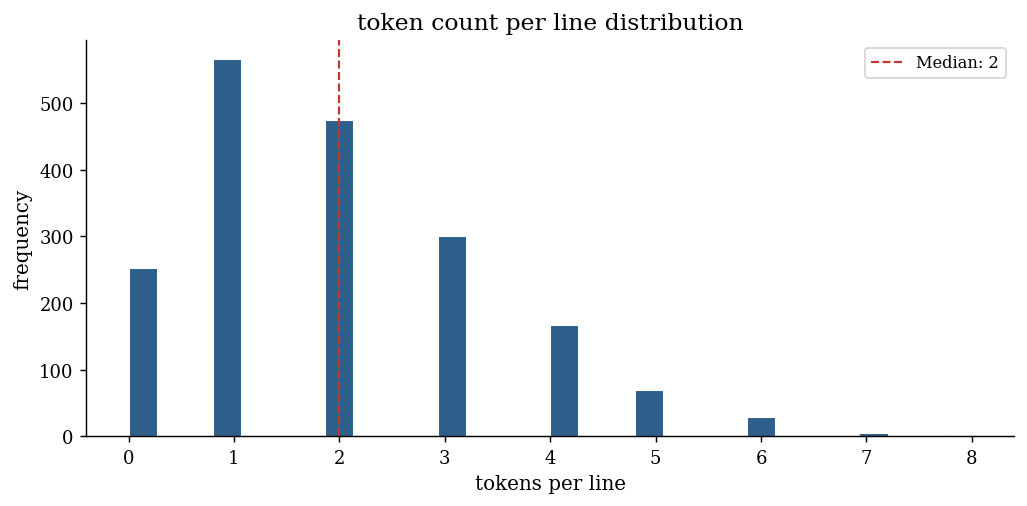

In [9]:
# tokens per line distribution
# explanation of each axis:
# x-axis: tokens per line — reveals whether slide text is predominantly short bullets or longer sentences.
# y-axis: frequency — how common each line length is across the corpus.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corpus['token_count'], bins=30, color=PALETTE[0], edgecolor='white', linewidth=0.6)
ax.axvline(corpus['token_count'].median(), color='#C0392B', linestyle='--',
           linewidth=1.2, label=f"Median: {corpus['token_count'].median():.0f}")
ax.set_xlabel('tokens per line')
ax.set_ylabel('frequency')
ax.set_title('token count per line distribution')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Term Frequency (TF)

Raw term frequency is computed at the **corpus level** — i.e., total occurrences across all slide decks. This gives a first view of the dominant vocabulary before any weighting.

In [10]:
# global term frequency analysis
all_tokens = [t for tokens in corpus['tokens'] for t in tokens]
freq       = Counter(all_tokens)
total_tokens = len(all_tokens)
vocab_size   = len(freq)

tf_df = pd.DataFrame(freq.most_common(), columns=['term', 'count'])
tf_df['tf'] = (tf_df['count'] / total_tokens).round(6)  # normalised TF

print(f'total tokens (corpus)  : {total_tokens:,}')
print(f'vocabulary size        : {vocab_size:,}')
print(f'type-token ratio (TTR) : {vocab_size / total_tokens:.4f}')
hapax = (tf_df['count'] == 1).sum()
print(f'Hapax legomena         : {hapax:,}  ({hapax/vocab_size:.1%} of vocabulary)') ## words that appear only once in the corpus, often indicating noise or very specific terms.
print()
tf_df.head(10)

total tokens (corpus)  : 3,663
vocabulary size        : 1,351
type-token ratio (TTR) : 0.3688
Hapax legomena         : 798  (59.1% of vocabulary)



,term,count,tf
0,dado,230,0.062790
1,modelo,58,0.015834
2,data,46,0.012558
3,variável,46,0.012558
4,valores,32,0.008736
5,informação,31,0.008463
6,objetivo,29,0.007917
7,ciência,27,0.007371
8,processo,27,0.007371
9,resultado,25,0.006825


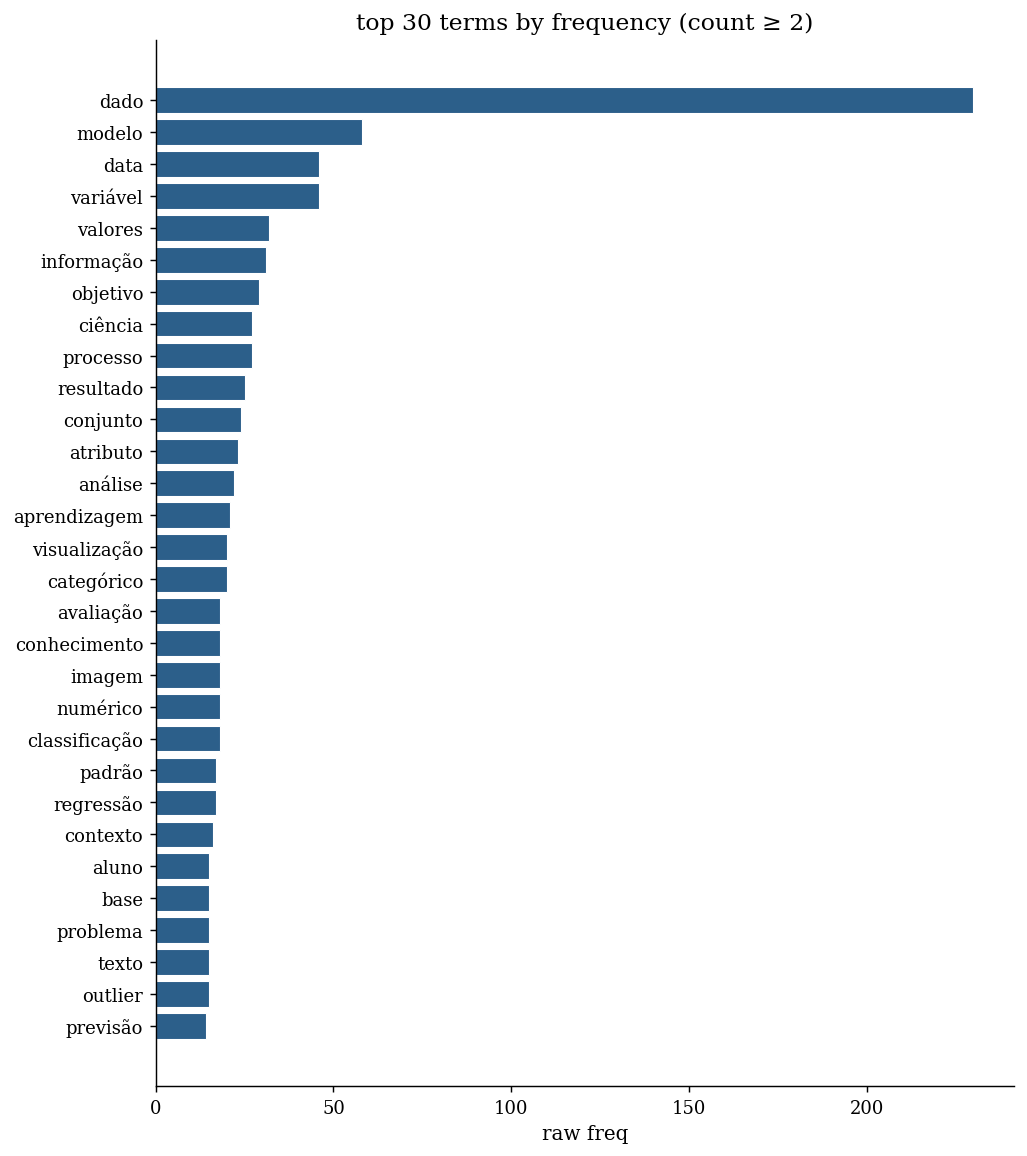

In [11]:
# top terms by frequency — hapax legomena (count=1) excluded from plot
TOP_N = 30
top_tf = tf_df[tf_df['count'] >= 2].head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(top_tf['term'][::-1], top_tf['count'][::-1],
        color=PALETTE[0], edgecolor='white', linewidth=0.6)
ax.set_xlabel('raw freq')
ax.set_title(f'top {TOP_N} terms by frequency (count ≥ 2)')
plt.tight_layout()
plt.show()

---
## 4. TF-IDF

In [12]:
# each document is the concatenation of all cleaned lines from that deck.
doc_texts = (
    corpus.groupby('source_file')['tokens']
    .apply(lambda rows: ' '.join(t for tokens in rows for t in tokens))
    .reset_index()
)
doc_texts.columns = ['source_file', 'clean_text']

vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[a-zA-ZÀ-ÿ]{3,}',  # consistent with tokenize(): includes PT accented chars, min 3 chars
    max_features=500,
    sublinear_tf=True,              # log-normalised TF; reduces effect of very high-frequency terms
    min_df=2,                       # discard terms appearing in only one document (likely noise)
)

tfidf_matrix = vectorizer.fit_transform(doc_texts['clean_text'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=doc_texts['source_file'],
    columns=vectorizer.get_feature_names_out()
)

print('TF-IDF matrix shape:', tfidf_df.shape)  # (n_docs, n_features)
tfidf_df.iloc[:, :10]  # preview first 10 terms

TF-IDF matrix shape: (9, 344)


,abordagem,académico,accuracy,aleatório,algorithms,algoritmo,algoritmos,aluno,alvo,amostra
source_file,,,,,,,,,,
icd_1_v1_cleaned_v7.csv,0.000000,0.063682,0.000000,0.000000,0.063682,0.043654,0.000000,0.116199,0.000000,0.055369
icd_2_v1_cleaned_v7.csv,0.000000,0.000000,0.000000,0.062333,0.000000,0.042729,0.000000,0.000000,0.062333,0.113738
icd_3_v1_cleaned_v7.csv,0.000000,0.105325,0.050188,0.000000,0.000000,0.072201,0.000000,0.104131,0.084976,0.000000
icd_4_v1_cleaned_v7.csv,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
icd_5_v1_cleaned_v7.csv,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
icd_6_v1_cleaned_v7.csv,0.115110,0.000000,0.000000,0.000000,0.000000,0.000000,0.115110,0.182032,0.000000,0.059112
icd_7_v1_cleaned_v7.csv,0.058276,0.000000,0.098669,0.058276,0.000000,0.095328,0.098669,0.000000,0.000000,0.000000
icd_8_v1_cleaned_v7.csv,0.000000,0.000000,0.000000,0.000000,0.000000,0.079969,0.000000,0.000000,0.000000,0.000000
icd_9_v1_cleaned_v7.csv,0.000000,0.000000,0.000000,0.000000,0.104483,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
# top tfidf per document
TOP_PER_DOC = 10

top_terms_per_doc = {}
for doc in tfidf_df.index:
    top_terms_per_doc[doc] = (
        tfidf_df.loc[doc]
        .sort_values(ascending=False)
        .head(TOP_PER_DOC)
    )

# Display as a readable table
summary_rows = []
for doc, series in top_terms_per_doc.items():
    for rank, (term, score) in enumerate(series.items(), 1):
        summary_rows.append({'document': doc, 'rank': rank, 'term': term, 'tfidf': round(score, 4)})

tfidf_summary = pd.DataFrame(summary_rows)
tfidf_summary

,document,rank,term,tfidf
0,icd_1_v1_cleaned_v7.csv,1,projeto,0.2036
1,icd_1_v1_cleaned_v7.csv,2,avaliação,0.1546
2,icd_1_v1_cleaned_v7.csv,3,prático,0.1520
3,icd_1_v1_cleaned_v7.csv,4,dado,0.1436
4,icd_1_v1_cleaned_v7.csv,5,numérico,0.1366
...,...,...,...,...
85,icd_9_v1_cleaned_v7.csv,6,imagem,0.1786
86,icd_9_v1_cleaned_v7.csv,7,estratégia,0.1769
87,icd_9_v1_cleaned_v7.csv,8,desafio,0.1769
88,icd_9_v1_cleaned_v7.csv,9,artificial,0.1769


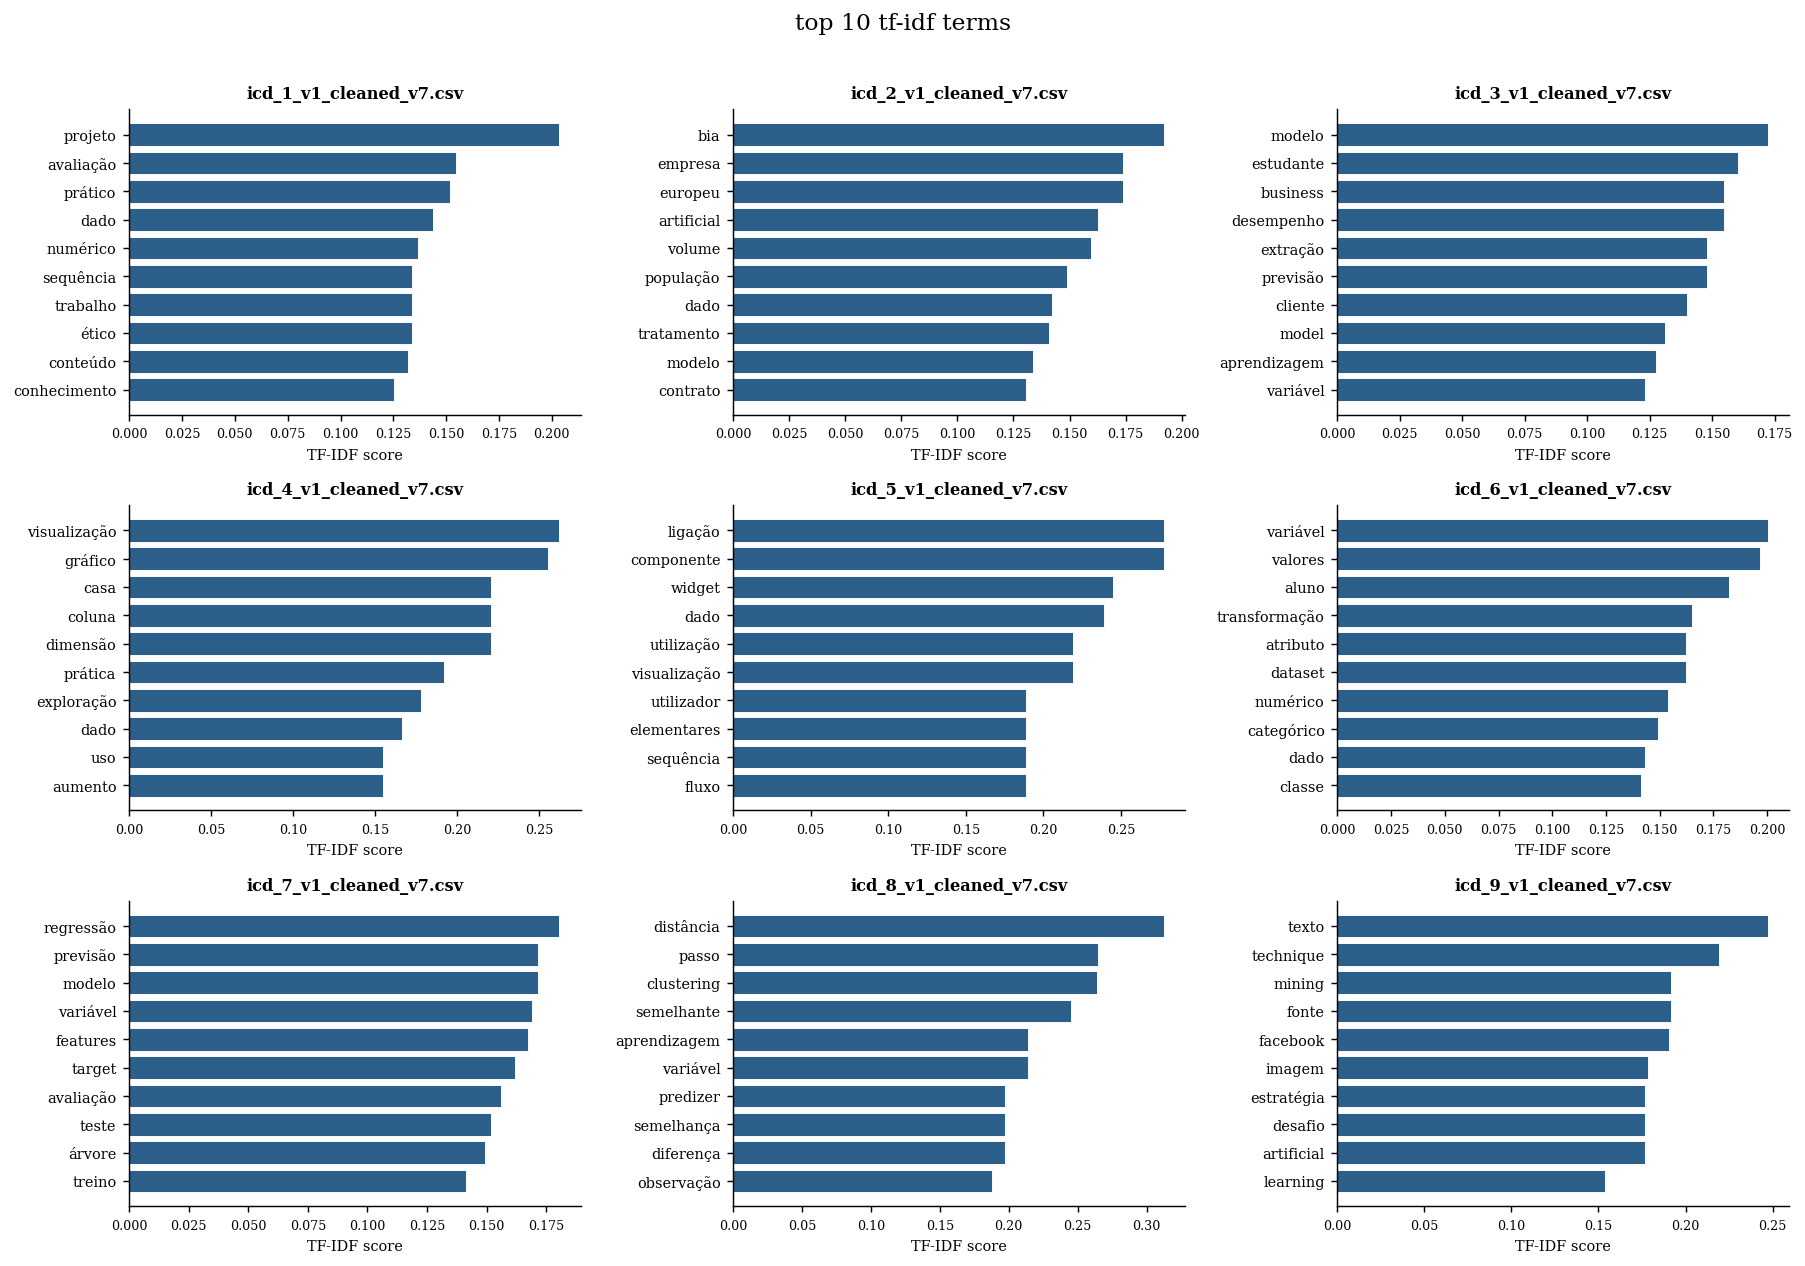

In [14]:
# top tfidf terms per document graph
n_docs = len(top_terms_per_doc)
ncols  = 3
nrows  = int(np.ceil(n_docs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = axes.flatten()

for i, (doc, series) in enumerate(top_terms_per_doc.items()):
    ax = axes[i]
    ax.barh(series.index[::-1], series.values[::-1],
            color=PALETTE[0], edgecolor='white', linewidth=0.5)
    ax.set_title(doc, fontsize=9, fontweight='bold')
    ax.set_xlabel('TF-IDF score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'top {TOP_PER_DOC} tf-idf terms',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

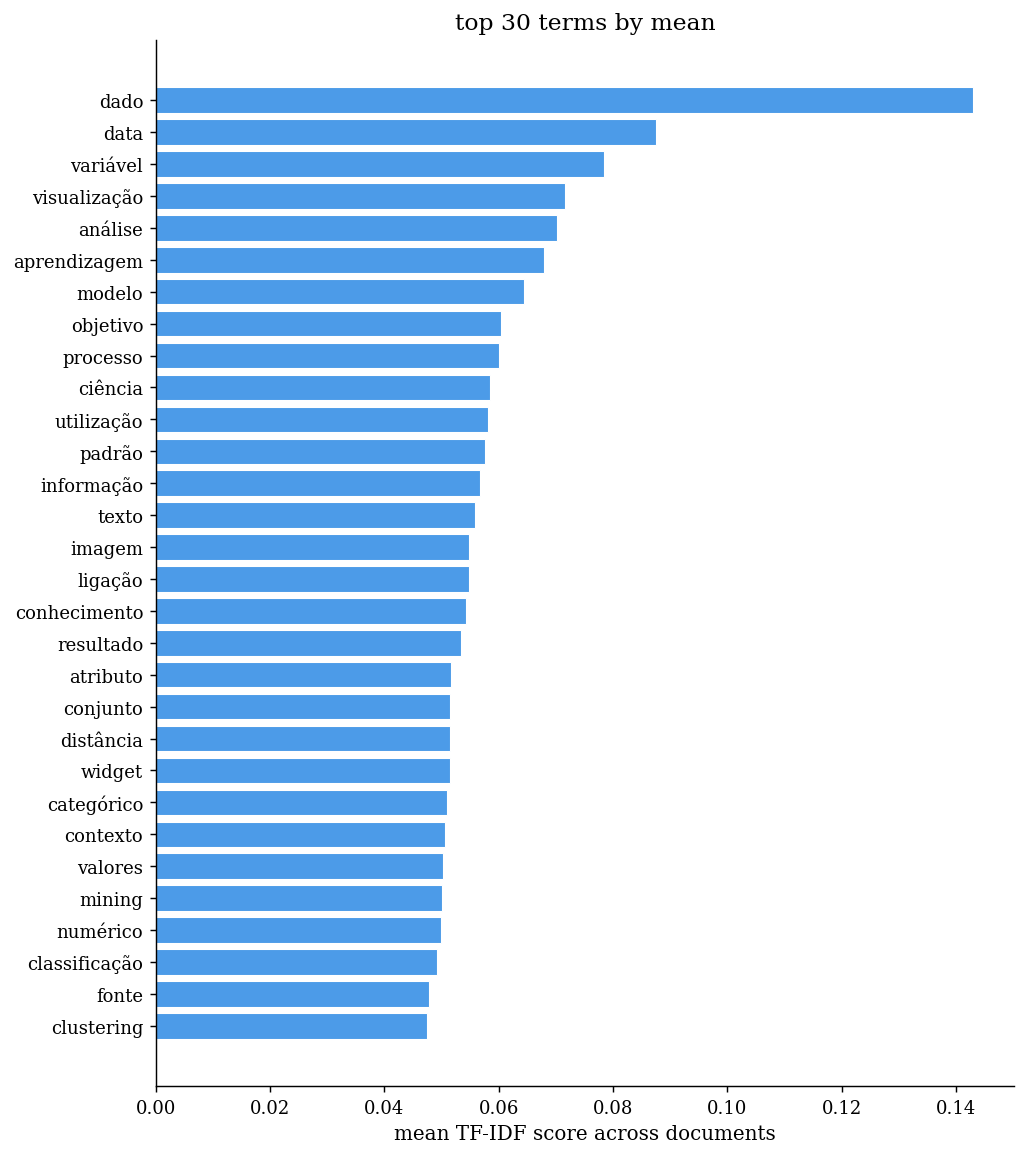

In [15]:
# corpus-wide mean TF-IDF
# high mean TF-IDF are specific to individual decks;
# low mean TF-IDF are shared across the corpus (less informative for topic separation).
mean_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False)
top_mean_tfidf = mean_tfidf.head(30)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(top_mean_tfidf.index[::-1], top_mean_tfidf.values[::-1],
        color=PALETTE[1], edgecolor='white', linewidth=0.6)
ax.set_xlabel('mean TF-IDF score across documents')
ax.set_title('top 30 terms by mean')
plt.tight_layout()
plt.show()

---
## 5. Word Cloud

Generated from the **raw term frequency** of the full corpus. Font size is proportional to frequency. Stopwords are already excluded from the token list used as input.

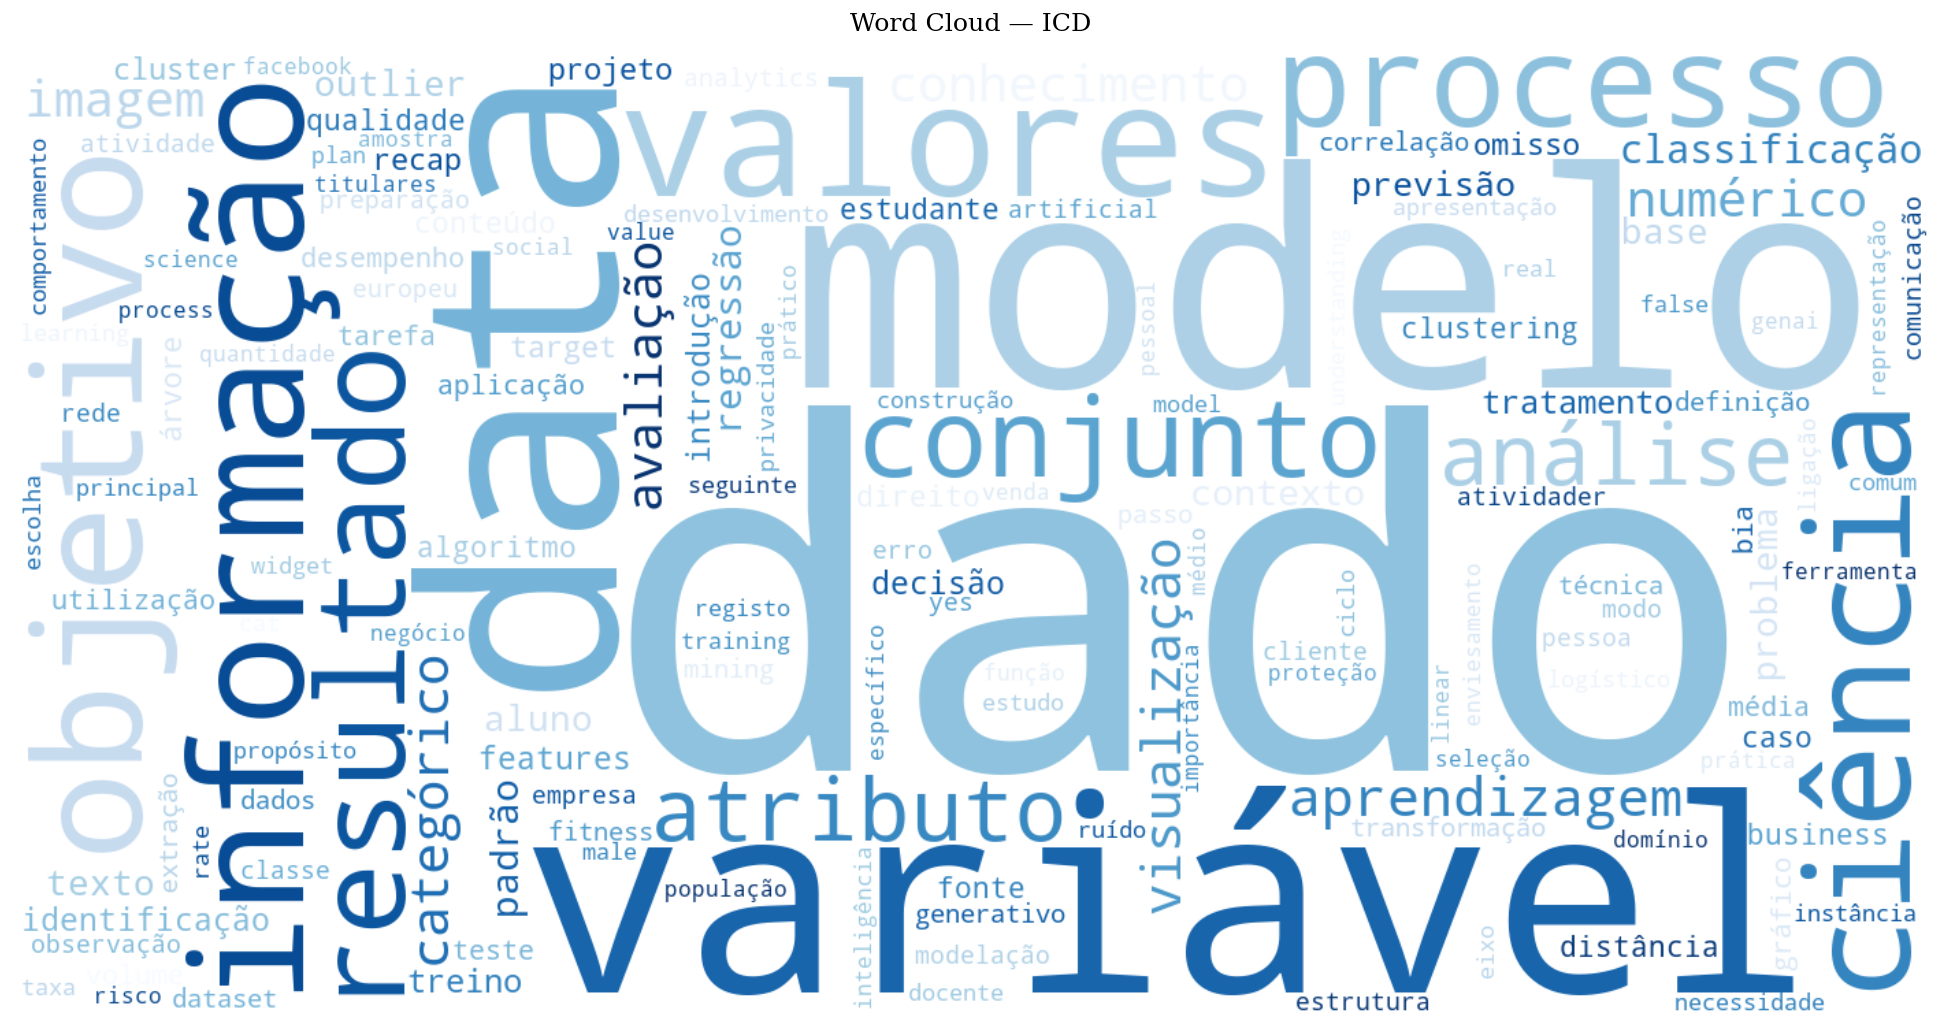

In [16]:
wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False,  # tokens already split; avoids spurious bigrams
    prefer_horizontal=0.85,
).generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — ICD', fontsize=14, pad=14)
plt.tight_layout()
plt.show()